In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LogisticRegression
from scipy.optimize import minimize
from termcolor import colored

In [2]:
df_votes = pd.read_parquet("../votes/votes.parquet")

In [3]:
df_conversations_0 = pd.read_parquet("../conversations/conversations_0.parquet")
df_conversations_1 = pd.read_parquet("../conversations/conversations_1.parquet")
df_conversations_2 = pd.read_parquet("../conversations/conversations_2.parquet")
df_conversations = pd.concat([df_conversations_0, df_conversations_1, df_conversations_2])

In [4]:
cols_votes = ['conversation_pair_id', 'conv_creative_a', 'conv_creative_b', 'chosen_model_name']
cols_conv = ['conversation_pair_id', 'total_conv_a_output_tokens', 'total_conv_b_output_tokens', 'model_a_name', 'model_b_name']

df_merged = pd.merge(
    df_votes[cols_votes],
    df_conversations[cols_conv],
    on='conversation_pair_id',
    how='inner'
)

df_merged = df_merged.dropna(subset=['total_conv_a_output_tokens', 'total_conv_b_output_tokens', 'chosen_model_name', 'model_a_name'])

df_merged['delta_tokens_A_minus_B'] = df_merged['total_conv_a_output_tokens'] - df_merged['total_conv_b_output_tokens']
df_merged['A_is_chosen'] = (df_merged['chosen_model_name'] == df_merged['model_a_name']).astype(int)

corr, p_val = pearsonr(df_merged['delta_tokens_A_minus_B'], df_merged['A_is_chosen'])

print("Quantification du biais de longueur :\n")
print(f"Taille de l'échantillon analysé : {len(df_merged)} duels")
print(f"Corrélation de Pearson          : {corr:.3f}")
print(f"P-value                         : {p_val:3E}")

Quantification du biais de longueur :

Taille de l'échantillon analysé : 35329 duels
Corrélation de Pearson          : 0.144
P-value                         : 1.193252E-163


Le biais de longueur est bien présent (P-value = 0), mais son impact est modéré (corrélation = 0.144)

In [5]:
X = df_merged[['delta_tokens_A_minus_B']] 
y = df_merged['A_is_chosen']

model_log = LogisticRegression()
model_log.fit(X, y)

coef_longueur = model_log.coef_[0][0] 
intercept = model_log.intercept_[0]

odds_ratio_longueur = np.exp(coef_longueur)

accuracy = model_log.score(X, y)

print("Prédiction par longueur")
print(f"Coefficient brut (Log-Odds) : {coef_longueur:.5f}")
print(f"Odds Ratio (multiplicateur) : {odds_ratio_longueur:.5f}")
print(f"Précision du modèle (Acc.)  : {accuracy:.3f}")

Prédiction par longueur
Coefficient brut (Log-Odds) : 0.00045
Odds Ratio (multiplicateur) : 1.00045
Précision du modèle (Acc.)  : 0.614


/home/augustin/.pyenv/versions/etude_de_cas/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


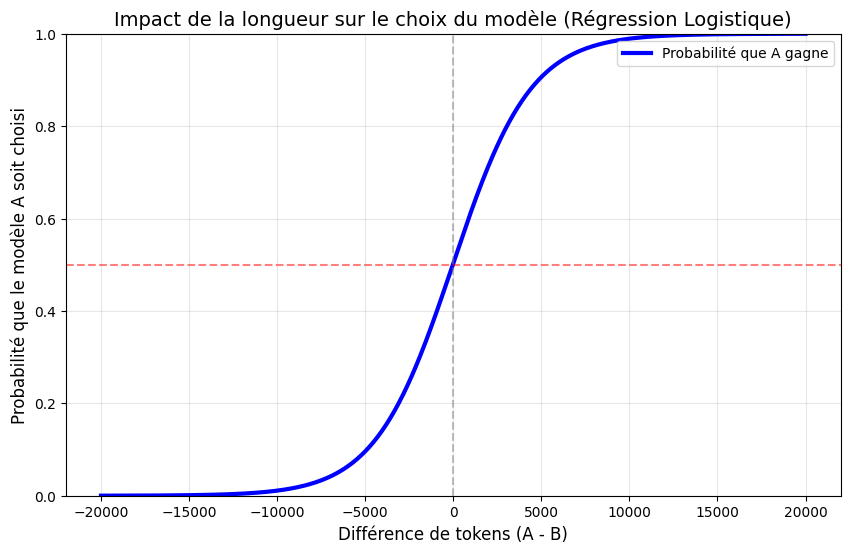

In [6]:
x_valeurs = np.linspace(-20000, 20000, 500).reshape(-1, 1)
probabilites = model_log.predict_proba(x_valeurs)[:, 1]

plt.figure(figsize=(10, 6))
plt.plot(x_valeurs, probabilites, color='blue', linewidth=3, label='Probabilité que A gagne')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.title("Impact de la longueur sur le choix du modèle (Régression Logistique)", fontsize=14)
plt.xlabel("Différence de tokens (A - B)", fontsize=12)
plt.ylabel("Probabilité que le modèle A soit choisi", fontsize=12)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Bradley-Terry 2.1 (code d'un autre notebook)

In [7]:
df_filtered = df_votes[df_votes["both_equal"] == False]

In [16]:
def get_occurences_model(df:pd.DataFrame) -> pd.Series:
    """Récupère les modèles et leur nombre d'occurrences dans les colonnes `model_a_name` et `model_b_name`."""
    model_names_a = df["model_a_name"].value_counts()
    model_names_b = df["model_b_name"].value_counts()

    # Mise en commun des deux séries
    return model_names_a.add(model_names_b, fill_value=0).sort_values(ascending=False)

model_names = get_occurences_model(df_filtered)
models = list(model_names[model_names >= 800].index)
kept_models = list(model_names[model_names >= 2000].index)

In [18]:
def build_ranking(model_names:list[str], df:pd.DataFrame) -> np.ndarray:
    """
    Construit la matrice de gain où W[i, j] est le nombre de fois que le modèle i a été préféré au modèle j dans les votes.
    """
    gains = np.zeros((len(model_names), len(model_names)), dtype=int)
    for row in df.itertuples():
        if row.model_a_name in model_names and row.model_b_name in model_names:
            i = model_names.index(row.model_a_name)
            j = model_names.index(row.model_b_name)
            if i == j:
                continue
            if row.chosen_model_name == row.model_a_name:
                gains[i, j] += 1
            elif row.chosen_model_name == row.model_b_name:
                gains[j, i] += 1
    return gains

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def compare_rankings(ranking1, ranking2, models, title1="Classement 1", title2="Classement 2"):
    """
    Compare deux classements en calculant leur corrélation de Spearman
    et en affichant une visualisation côte à côte.

    Args:
        ranking1 (np.ndarray): Premier classement (indices des modèles).
        ranking2 (np.ndarray): Deuxième classement (indices des modèles).
        title1 (str): Titre du premier classement.
        title2 (str): Titre du deuxième classement.
    """
    ranks_1_by_model = np.argsort(ranking1)
    ranks_2_by_model = np.argsort(ranking2)

    # Calcul du coefficient de corrélation de Spearman
    spearman_corr, p_value = spearmanr(ranks_1_by_model, ranks_2_by_model)

    # Visualisation des classements
    plt.figure(figsize=(6, 5))

    # Classement 1 en fonction du classement 2
    plt.scatter(ranks_1_by_model, ranks_2_by_model, color='blue')
    plt.plot([0, len(models)-1], [0, len(models)-1], color='green')
    plt.plot([5, len(models)-1], [0, len(models)-6], color='red', linestyle='--')
    plt.plot([0, len(models)-6], [5, len(models)-1], color='red', linestyle='--', label="±5 positions")
    plt.title(f"{title1} vs {title2}")
    plt.xlabel(f"Rang du modèle selon {title1}")
    plt.ylabel(f"Rang du modèle selon {title2}")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Affichage du résultat
    print(f"Coefficient de Spearman : {spearman_corr:.3f}")
    print(f"P-value : {p_value:.2E}")

    # Top 5 des pires changement de rangs
    rank_diff = np.abs(ranks_1_by_model - ranks_2_by_model)
    worst_changes = np.argsort(rank_diff)[-10:]
    print("\nTop 10 des pires changements de rangs :")
    for idx in worst_changes[::-1]:
        print(f"{colored(models[idx], "red")} : {title1} = {ranks_1_by_model[idx]}, {title2} = {ranks_2_by_model[idx]}, {colored("Différence", "blue")} = {rank_diff[idx]}")

In [20]:
def estimate_bradley_terry(W: np.ndarray, tol: float = 1e-8, max_iter: int = 10000):
    """
    Estime les paramètres β du modèle de Bradley-Terry via l'algorithme
    itératif original (Bradley & Terry 1952 / Hunter 2004 MM).

    Args:
        W        : matrice (k, k) — W[i,j] = nb de victoires de i sur j
        tol      : critère d'arrêt sur la variation max de β
        max_iter : garde-fou

    Returns:
        beta     : paramètres estimés (non normalisés)
        ranking  : indices triés par β décroissant
    """
    k = W.shape[0]
    beta = np.ones(k)

    # Wins totaux de chaque modèle — constants, précalculés hors boucle
    W_wins = W.sum(axis=1)          # W_wins[i] = nombre total de victoires de i
    W_total = W + W.T               # W_total[i,j] = duels totaux entre i et j

    for i in range(max_iter):
        beta_old = beta.copy()

        # Mise à jour simultanée de tous les β (forme vectorisée)
        # denom[i] = Σⱼ≠ᵢ  (Wᵢⱼ + Wⱼᵢ) / (βᵢ + βⱼ)
        denom = (W_total / (beta[:, None] + beta[None, :])).sum(axis=1)

        # Éviter division par zéro pour les modèles sans aucune victoire
        beta = np.where(W_wins > 0, W_wins / denom, 1e-10)

        # Normalisation pour fixer l'identifiabilité (sum = k)
        beta /= beta.mean()

        if np.max(np.abs(beta - beta_old)) < tol:
            print(f"Convergence atteinte après {i+1} itérations.")
            break

    ranking = np.argsort(beta)[::-1]
    return beta, ranking

In [27]:
gains = build_ranking(kept_models, df_filtered)

In [28]:
beta_global, ranking_global = estimate_bradley_terry(gains)

Convergence atteinte après 101 itérations.


### Bradley-Terry corrigé

Optimisation du modèle BT avec longueur sur 19561 duels...
Paramètre Gamma (Avantage par token) : 0.00043


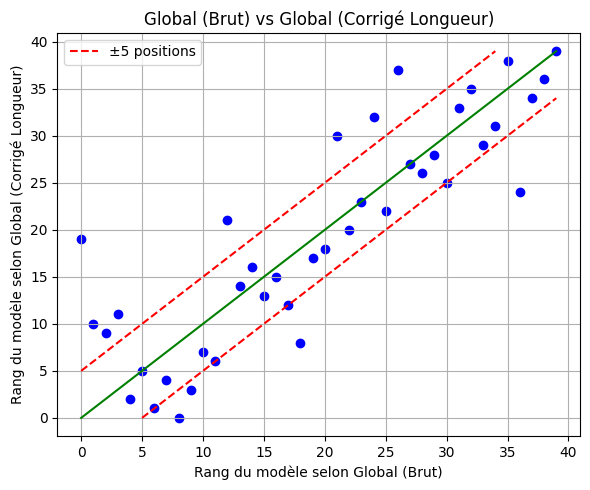

Coefficient de Spearman : 0.863
P-value : 8.32E-13

Top 10 des pires changements de rangs :
mistral-large-2512 : Global (Brut) = 0, Global (Corrigé Longueur) = 19, Différence = 19
llama-3.1-405b : Global (Brut) = 36, Global (Corrigé Longueur) = 24, Différence = 12
gpt-5 : Global (Brut) = 26, Global (Corrigé Longueur) = 37, Différence = 11
gemini-1.5-pro : Global (Brut) = 18, Global (Corrigé Longueur) = 8, Différence = 10
gpt-5-mini : Global (Brut) = 21, Global (Corrigé Longueur) = 30, Différence = 9
mistral-medium-2508 : Global (Brut) = 1, Global (Corrigé Longueur) = 10, Différence = 9
gemma-3n-e4b-it : Global (Brut) = 12, Global (Corrigé Longueur) = 21, Différence = 9
qwen3-30b-a3b : Global (Brut) = 24, Global (Corrigé Longueur) = 32, Différence = 8
gemini-2.0-flash : Global (Brut) = 3, Global (Corrigé Longueur) = 11, Différence = 8
claude-4-5-sonnet : Global (Brut) = 8, Global (Corrigé Longueur) = 0, Différence = 8


In [29]:
def estimate_bradley_terry_with_length(df: pd.DataFrame, models: list[str]):
    """
    Estime les paramètres β du modèle de Bradley-Terry en contrôlant le biais de longueur (γ).
    Retourne des β multiplicatifs compatibles avec l'algorithme itératif MM de Hunter.
    """
    n_models = len(models)
    
    # On initialise avec des logits à 0 (ce qui correspondra à un beta de 1)
    params_init = np.zeros(n_models + 1)

    models_str = [str(m) for m in models]
    
    # Filtrage sécurisé
    mask_models_valid = df['model_a_name'].astype(str).isin(models_str) & df['model_b_name'].astype(str).isin(models_str)
    mask_chosen_valid = (df['chosen_model_name'] == df['model_a_name']) | (df['chosen_model_name'] == df['model_b_name'])
    
    df_filtered = df[mask_models_valid & mask_chosen_valid].copy()
    
    # Vectorisation des indices
    idx_a = pd.Categorical(df_filtered['model_a_name'].astype(str), categories=models_str).codes
    idx_b = pd.Categorical(df_filtered['model_b_name'].astype(str), categories=models_str).codes
    
    # Différence de longueur et cible
    delta_len = (df_filtered['total_conv_a_output_tokens'] - df_filtered['total_conv_b_output_tokens']).astype(float).values
    y = (df_filtered['chosen_model_name'] == df_filtered['model_a_name']).astype(float).values
    
    def log_likelihood(params):
        # L'optimiseur travaille avec des logits (scores additifs)
        theta = params[:-1]
        gamma = params[-1]
        
        logits = theta[idx_a] - theta[idx_b] + gamma * delta_len
        loss = np.sum(np.logaddexp(0, -logits) * y + np.logaddexp(0, logits) * (1 - y))
        return loss
        
    print(f"Optimisation du modèle BT avec longueur sur {len(df_filtered)} duels...")
    result = minimize(log_likelihood, params_init, method='L-BFGS-B')
    
    theta_estimated = result.x[:-1]
    gamma_estimated = result.x[-1]
    
    beta_estimated = np.exp(theta_estimated)
    
    beta_estimated /= beta_estimated.mean()
    
    ranking = np.argsort(beta_estimated)[::-1]
    
    print(f"Paramètre Gamma (Avantage par token) : {gamma_estimated:.5f}")
    
    return beta_estimated, gamma_estimated, ranking

beta_corrected, gamma_corrected, ranking_corrected = estimate_bradley_terry_with_length(df_merged, kept_models)

compare_rankings(ranking_global, ranking_corrected, kept_models, "Global (Brut)", "Global (Corrigé Longueur)")

Le classement après correction de la longueur ne ressemble plus du tout au classement initial (basé uniquement sur l'évaluation humaine). On peut en déduire qu'il était effectivement biaisé par la longueur des réponses.

In [15]:
df_a = df_merged[['model_a_name', 'total_conv_a_output_tokens']].rename(
    columns={'model_a_name': 'model', 'total_conv_a_output_tokens': 'tokens'}
)
df_b = df_merged[['model_b_name', 'total_conv_b_output_tokens']].rename(
    columns={'model_b_name': 'model', 'total_conv_b_output_tokens': 'tokens'}
)

df_lengths = pd.concat([df_a, df_b])

mean_lengths = df_lengths.groupby('model')['tokens'].mean().reset_index()

ranks_global = np.argsort(ranking_global)
ranks_corrected = np.argsort(ranking_corrected)

df_ranks = pd.DataFrame({
    'model': models,
    'rang_brut': ranks_global,
    'rang_corrige': ranks_corrected
})
df_ranks['gain_places'] = df_ranks['rang_brut'] - df_ranks['rang_corrige']

df_analysis = pd.merge(df_ranks, mean_lengths, on='model')

print("Modèles ayant gagné le plus de places :\n")
print(df_analysis.sort_values(by='gain_places', ascending=False).head(5).to_string(index=False))

print("\n--------------------------------------------------------------------------------------\n")

print("Modèles ayant perdu le plus de places :\n")
print(df_analysis.sort_values(by='gain_places', ascending=True).head(5).to_string(index=False))

print("\n--------------------------------------------------------------------------------------\n")

corr, pval = pearsonr(df_analysis['tokens'], df_analysis['gain_places'])
print(f"Vérification statistique\n")
print(f"Corrélation Longueur <-> Gain de places : {corr:.3f}")
print(f"P-value : {pval:.5f}")

Modèles ayant gagné le plus de places :

                          model  rang_brut  rang_corrige  gain_places      tokens
                 llama-3.1-405b         67            25           42  766.706346
                 gemini-1.5-pro         39            12           27  858.633197
mistral-small-24b-instruct-2501         48            22           26  800.430079
              claude-3-7-sonnet         27             4           23  892.611523
               olmo-3-32b-think         73            52           21 3631.535714

--------------------------------------------------------------------------------------

Modèles ayant perdu le plus de places :

               model  rang_brut  rang_corrige  gain_places      tokens
  mistral-large-2512          0            43          -43 2144.744186
             glm-4.5         22            63          -41 2193.660232
             glm-4.6         31            66          -35 3166.137931
  deepseek-chat-v3.1         14            45        

L'intégration de la longueur des réponses comme covariable dans le modèle de Bradley-Terry révèle que le classement initial (brut) était fortement faussé par un biais de verbosité de la part des utilisateurs.
- Les modèles "bavards" : En neutralisant l'avantage mathématique lié à la quantité de texte généré, les modèles produisant les réponses les plus longues (ex: mistral-large-2512, glm-4.5) chutent lourdement dans le classement. Leur position dominante était en grande partie due à l'illusion de qualité procurée par la longueur.
- Les modèles "concis" : À l'inverse, les modèles allant à l'essentiel avec des réponses courtes (ex: llama-3.1-405b, gemini-1.5-pro) connaissent un bond spectaculaire de plusieurs dizaines de places. À longueur de texte égale, leur qualité intrinsèque se révèle bien supérieure.
- Vérification statistique : L'analyse confirme une corrélation fortement négative entre la longueur moyenne générée par un modèle et son évolution au classement. Plus un modèle est verbeux en moyenne, plus la correction mathématique le sanctionne.

Sans correction, un classement basé sur des votes humains a tendance à récompenser la quantité au détriment de la qualité pure.